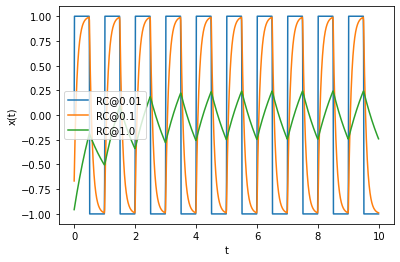

In [10]:
# Comp.Phys.HW6.Q1 : Exercise 8.1 RC Low-Filter Circuit

from numpy import arange
from pylab import plot, show, xlim, xlabel, ylabel, legend

a = 0.0
b = 10.0
N = 1000
h = (b-a)/N
V_out = 0.0

# square-wave
def V_in(t):
    if (int(2*(t)) %  2) == 0: return 1
    else: return -1
    
# E.O.M to solve
def f(x,t,RC):
    return ((V_in(t) - V_out)/RC)

tpoints = arange(a,b,h)
vpoints_1 = []
vpoints_2 = []
vpoints_3 = []

x = V_out
for t in tpoints:
    vpoints_1.append(V_out)
    k1 = h*f(x,t,0.01)
    k2 = h*f(x+0.5*k1, t+0.5*h, 0.01)
    k3 = h*f(x+0.5*k2, t+0.5*h, 0.01)
    k4 = h*f(x+k3, t+h, 0.01)
    V_out += (k1+2*k2+2*k3+k4) / 6
plot(tpoints, vpoints_1, label="RC@0.01")

for t in tpoints:
    vpoints_2.append(V_out)
    k1 = h*f(x,t,0.1)
    k2 = h*f(x+0.5*k1, t+0.5*h, 0.1)
    k3 = h*f(x+0.5*k2, t+0.5*h, 0.1)
    k4 = h*f(x+k3, t+h, 0.1)
    V_out += (k1+2*k2+2*k3+k4) / 6
plot(tpoints, vpoints_2, label="RC@0.1")

for t in tpoints:
    vpoints_3.append(V_out)
    k1 = h*f(x,t,1.0)
    k2 = h*f(x+0.5*k1, t+0.5*h, 1.0)
    k3 = h*f(x+0.5*k2, t+0.5*h, 1.0)
    k4 = h*f(x+k3, t+h, 1.0)
    V_out += (k1+2*k2+2*k3+k4) / 6
plot(tpoints, vpoints_3, label="RC@1.0")

xlabel("t")
ylabel("x(t)")
legend()
show()

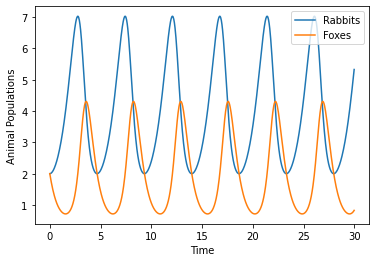

In [8]:
# Comp.Phys.HW6.Q2 : Exercise 8.2 Predator/Prey

import numpy as np
from numpy import arange, array
from pylab import plot, show, xlim, xlabel, ylabel, legend

alpha = 1.0
beta = 0.5
delta = 2.0
gamma = 0.5
a = 0.0
b = 30.0
N = 1000
h = (b-a)/N
r = np.array([2, 2], float)

# pred-prey function
def f(r,t):
    x = r[0]
    y = r[1]
    fx = x*alpha-beta*y*x
    fy = y*(-delta)+gamma*x*y
    return np.array([fx,fy], float)

tpoints = arange(a, b, h)
xpoints = []
ypoints = []

for t in tpoints:
    xpoints.append(r[0])
    ypoints.append(r[1])
    k1 = h*f(r,t)
    k2 = h*f(r+0.5*k1,t+0.5*h)
    k3 = h*f(r+0.5*k2,t+0.5*h)
    k4 = h*f(r+k3,t+h)
    r += (k1 + 2*k2 + 2*k3 + k4) / 6


plot(tpoints, xpoints, label="Rabbits")
plot(tpoints, ypoints, label="Foxes")
xlabel("Time")
ylabel("Animal Populations")
legend()
show()

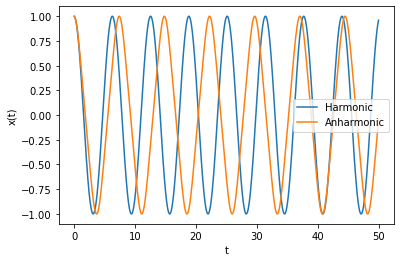

In [9]:
# Comp.Phys.HW6.Q3 : Exercise 8.6 Harmonic and Anharmonic
# Parts (a) - (c)

import numpy as np
from numpy import arange
from pylab import plot, show, xlim, xlabel, ylabel, legend

# d^2x/dt^2 = -omega**2 * x -- need two 1st order eqns!
# --> v = dx/dt 
# --> SO THEN --> dv/dt = -omega^2x

# params
omega = 1.0
tmin = 0
tmax = 50
N = 1000
h = (tmax - tmin)/N
x_init = 1.0
v_init = 0.0

# harmonic E.O.M
def f(r,v):
    dvdt = -(omega)**2*r # two 1st-order eqns
    return v+dvdt*h, dvdt 
    
# anharmonic E.O.M
def ff(r,v):
    dvdt = -(omega)**2*r**3 # two 1st-order eqns
    return v+dvdt*h, dvdt

tpoints = arange(tmin,tmax,h)
xpoints_1 = []
xpoints_2 = []

# redef of vars before sending through harmonic loop
x = x_init
v = v_init

# harmonic loop
for t in tpoints:
    xpoints_1.append(x)
    v, dvdt = f(x,v)
    x += v*h

# redef vars before sending through anharmonic loop
x = x_init
v = v_init
    
# anharmonic loop
for t in tpoints:
    xpoints_2.append(x)
    v, dvdt = ff(x,v)
    x += v*h


plot(tpoints, xpoints_1, label="Harmonic")
plot(tpoints, xpoints_2, label="Anharmonic")
xlabel("t")
ylabel("x(t)")
legend()
show()

# here my plots show both harmonic and anharmonic oscillations
# I can change x_init (amplitude) to = 2.0 to change the plot
# changing x_init = 6.0 for example gets quite crazy
# same can be done with anharmonic amplitude
# this cell covers question 8.6 parts (a) - (c)

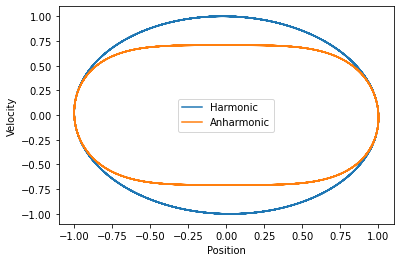

In [6]:
# phase space plot of harmonic/anharmoic motion
# I simply create two lists of xpoints and two lists of vpoints
# I then append them approp. in their for-loops
# Lastly, I plot xpoints and vpoints
# Rather than tpoints and xpoints -- like the above plots show

import numpy as np
from numpy import arange
from pylab import plot, show, xlim, xlabel, ylabel, legend

# d^2x/dt^2 = -omega**2 * x -- need two 1st order eqns!
# --> v = dx/dt 
# --> SO THEN --> dv/dt = -omega^2x

# params
omega = 1.0
tmin = 0
tmax = 50
N = 1000
h = (tmax - tmin)/N
x_init = 1.0
v_init = 0.0

# harmonic E.O.M
def f(r,v):
    dvdt = -(omega)**2*r # two 1st-order eqns
    return v+dvdt*h, dvdt 
    
# anharmonic E.O.M
def ff(r,v):
    dvdt = -(omega)**2*r**3 # two 1st-order eqns
    return v+dvdt*h, dvdt

tpoints = arange(tmin,tmax,h)
xpoints_1 = []
xpoints_2 = []
vpoints_1 = []
vpoints_2 = []

# redef of vars before sending through harmonic loop
x = x_init
v = v_init

# harmonic loop
for t in tpoints:
    xpoints_1.append(x)
    v, dvdt = f(x,v)
    vpoints_1.append(v)
    x += v*h

# redef vars before sending through anharmonic loop
x = x_init
v = v_init
    
# anharmonic loop
for t in tpoints:
    xpoints_2.append(x)
    v, dvdt = ff(x,v)
    vpoints_2.append(v)
    x += v*h


plot(xpoints_1, vpoints_1, label="Harmonic")
plot(xpoints_2, vpoints_2, label="Anharmonic")
xlabel("Position")
ylabel("Velocity")
legend()
show()

# the plot circles around the given amplitude of x_init = 1.0
# changing x_init (or v_init) changes plot quite interestingly
# this cell covers question 8.6 part (d)

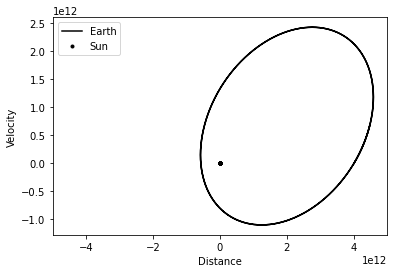

In [5]:
# Comp.Phys.HW6.Q4 : Exercise 8.12 Earth orbit around Sun

from math import sqrt
from numpy import array
from pylab import plot, show, xlim, xlabel, ylabel, legend

# parameters
G = 6.674e-11 # gravity
M = 1.989e30  # mass of Sun
m = 5.972e24  # mass of Earth
h = 1.0e5     # step-size
tmax = 5.0e9  # large amount of time -- to capture full orbit
x0 = 4.0e12   # init position -- x-direction
y0 = 0.0      # init position -- y-direction
u0 = 0.0      # init velocity -- x-direction
v0 = sqrt(G*M/x0) # init velocity -- y-direction
vhalf = v0 / 2 # init velocity / 2

# functions
def f(r):
    x = r[0]
    y = r[1]
    rcubed = (x*x + y*y)**1.5
    fu = -G*M*x/rcubed
    fv = -G*M*y/rcubed
    return array([fu,fv],float) 


r = array([x0,y0],float) # position array
v = array([u0,v0],float) # velocity array
xpoints = []
ypoints = []
upoints = []
vpoints = []
xpoints.append(x0)
ypoints.append(y0)
upoints.append(u0)
vpoints.append(v0)

t = 0.0
while t < tmax:
    r += h*vhalf
    k = h*f(r)
    v = vhalf + 0.5*k
    vhalf += k
    xpoints.append(r[0])
    ypoints.append(r[1])
    upoints.append(v[0])
    vpoints.append(v[1])
    t += h 

# Plots for Earth's orbit around Sun
plot(xpoints, ypoints, "k-", label="Earth")
plot(upoints, vpoints, "k.", label="Sun")

# Plot params.
xlim(-5.0e12,5.0e12)
xlabel("Distance")
ylabel("Velocity")
legend()
show()

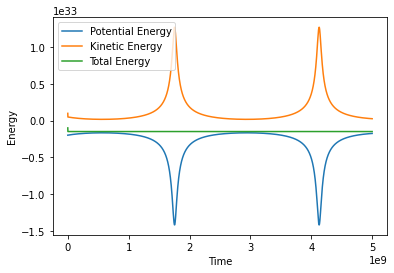

In [4]:
# Comp.Phys.HW6.Q4 : Exercise 8.12 -- Energy of Earth's Orbit

from math import sqrt
from numpy import array
from pylab import plot, show, xlim, xlabel, ylabel, legend

# parameters
G = 6.674e-11 # gravity
M = 1.989e30  # mass of Sun
m = 5.972e24  # mass of Earth
h = 1.0e5     # step-size
tmax = 5.0e9  # large amount of time -- to capture full orbit
x0 = 4.0e12   # init position -- x-direction
y0 = 0.0      # init position -- y-direction
u0 = 0.0      # init velocity -- x-direction
v0 = sqrt(G*M/x0) # init velocity -- y-direction
vhalf = v0 / 2 # init velocity / 2

# functions
def f(r):
    x = r[0]
    y = r[1]
    rcubed = (x*x + y*y)**1.5
    fu = -G*M*x/rcubed
    fv = -G*M*y/rcubed
    return array([fu,fv],float) 

r = array([x0,y0],float) # position array
v = array([u0,v0],float) # velocity array
# xpoints = []
# ypoints = []
# upoints = []
# vpoints = []
# xpoints.append(x0)
# ypoints.append(y0)
# upoints.append(u0)
# vpoints.append(v0)
tpoints = [0.0]

# energy eqns
PE = [-G * M * m / x0]
KE = [0.5 * m * v0**2]
TE = [KE[0] + PE[0]]

t = 0.0
while t < tmax:
    r += h * vhalf
    k = h * f(r)
    v = vhalf + 0.5 * k
    vhalf += k
#     xpoints.append(r[0])
#     ypoints.append(r[1])
    t += h
    tpoints.append(t)
    PE.append(-G * M * m / sqrt(r[0]**2 + r[1]**2))
    KE.append(0.5 * m * (v[0]**2 + v[1]**2))
    TE.append(KE[-1] + PE[-1]) # [-1] gets value at current t

plot(tpoints, PE, label='Potential Energy')
plot(tpoints, KE, label='Kinetic Energy')
plot(tpoints, TE, label='Total Energy')
xlabel("Time")
ylabel("Energy")
legend()
show()

# just modified code from last cell -- no need to consider x,y,u,v
# plot shows PE go down as KE goes up
# while TE stays roughly the same
# plotting TE alone reveals a slight change during orbit